In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize as opt


In [197]:
def my_analytic_gap_function(x,T, guess = 0.24, eta = 1e-5):
    f = lambda gap: np.tanh(0.5*x/T) / np.sqrt(gap**2 - (x + 1j*eta)**2)
    integral = lambda gap: (1 - 1/3 * np.imag(np.trapz(f(gap),x)))
    sol = opt.root(integral,guess)
    return sol

    ## add sign of x (x+ieta)**2 




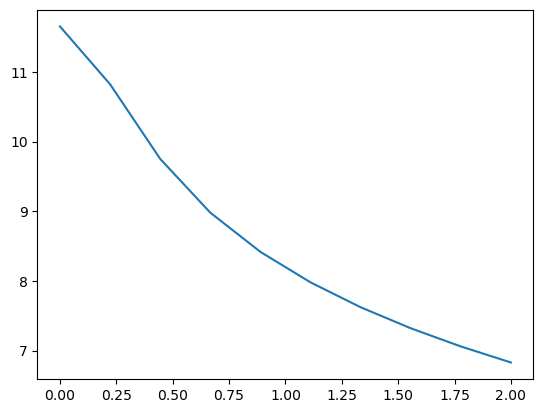

In [198]:
x =  np.linspace(-30,30,10000)
gaps = np.linspace(0,2,10)
eta = 1e-3
sols = []
T = 0.1 
for gap in gaps:
    f = lambda gap: np.tanh(0.5*x/T) / np.sqrt(gap**2 - (x + 1j*eta)**2)
    sols += [np.imag(np.trapz(f(gap),x))]

plt.plot(gaps,sols)
plt.show()



In [199]:
xs = np.linspace(-5,5,100000)
T = 0.01
sol = my_analytic_gap_function(xs,T)
print(sol)
print(sol.x)

 message: The solution converged.
 success: True
  status: 1
     fun: -3.3092728557448936e-10
       x: [ 2.129e+00]
    nfev: 24
    fjac: [[-1.000e+00]]
       r: [-3.986e+02]
     qtf: [-3.404e-07]
[2.12877583]


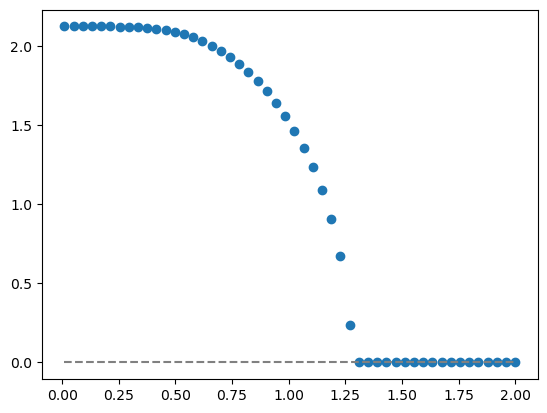

In [200]:
xs = np.linspace(-5,5,10000)
Ts = np.linspace(0.01,2,50)
sols = [0.18]
for T in Ts:
    sol = my_analytic_gap_function(xs,T, guess = sols[-1], eta = 1e-3)
    #print(T,sol.x)
    sols += [np.abs(sol.x)]

plt.scatter(Ts,sols[1:])
plt.plot(Ts, np.ones(np.size(Ts)) * 0,color='gray',linestyle='dashed')

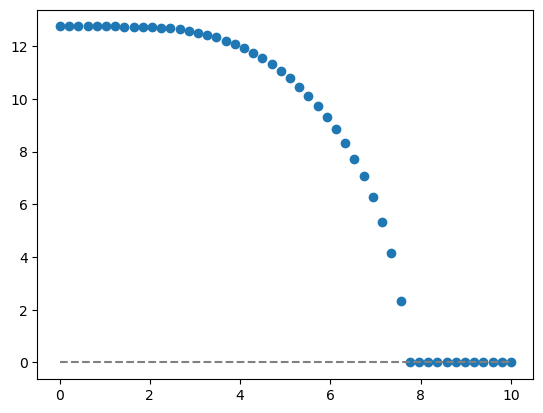

In [203]:
xs = np.linspace(-30,30,10000)
Ts = np.linspace(0.01,10,50)
sols = [0.65]
for T in Ts:
    sol = my_analytic_gap_function(xs,T, guess = sols[-1], eta = 1e-2)
    #print(T,sol.x)
    sols += [np.abs(sol.x)]

plt.scatter(Ts,sols[1:])
plt.plot(Ts, np.ones(np.size(Ts)) * 0,color='gray',linestyle='dashed')

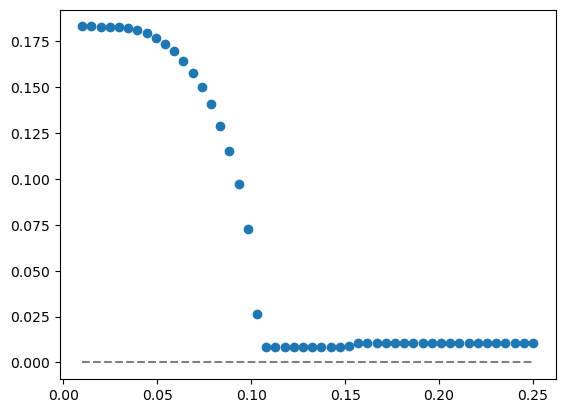

In [119]:
xs = np.linspace(1e-3,5,500000)
Ts = np.linspace(0.01,0.25,50)
sols = [0.18]
for T in Ts:
    sol = my_analytic_gap_function(xs,T, guess = sols[-1], eta = 5e-6)
    #print(T,sol.x)
    sols += [np.abs(sol.x)]

plt.scatter(Ts,sols[1:])
plt.plot(Ts, np.ones(np.size(Ts)) * 0,color='gray',linestyle='dashed')